# LAB PROBLEM STATEMENT 6 – R PROGRAMMING LAB

## Statistical Analysis of Physical Characteristics of Palmer Penguins

**Name:** Tamanna Shaikh  
**Roll No.:** 24102A2006  
**Branch:** CMPN -A  

### Objective
To perform a comprehensive statistical analysis of the Palmer Penguins dataset using descriptive statistics, hypothesis testing, effect-size estimation, ANOVA, post-hoc analysis, non-parametric tests, and suitable visualizations.

### Dataset
**Palmer Penguins Dataset – UCI Machine Learning Repository**



## Setup and Required Libraries

In [12]:
# Step 1: Load Palmer Penguins Dataset

library(palmerpenguins)

data(penguins)

head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


In [13]:
# Step 2: Descriptive Statistics of Body Mass

body_mass <- na.omit(penguins$body_mass_g)

mean(body_mass)
median(body_mass)
min(body_mass)
max(body_mass)
var(body_mass)
sd(body_mass)
quantile(body_mass, 0.25)
quantile(body_mass, 0.75)
IQR(body_mass)

[1] 4201.754

[1] 4050

[1] 2700

[1] 6300

[1] 643131.1

[1] 801.9545

25% 
3550

75% 
4750

[1] 1200

In [14]:
# Step 3: Skewness and Kurtosis

install.packages("moments")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [15]:
library(moments)

skewness(body_mass)
kurtosis(body_mass)

[1] 0.468264

[1] 2.273757

In [16]:
# Step 4: Species-wise Descriptive Statistics

tapply(penguins$body_mass_g, penguins$species, mean, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species, median, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species, min, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species, max, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species, var, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species, sd, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species,
       quantile, probs = 0.25, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species,
       quantile, probs = 0.75, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species,
       IQR, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species,
       skewness, na.rm = TRUE)

tapply(penguins$body_mass_g, penguins$species,
       kurtosis, na.rm = TRUE)

Adelie Chinstrap    Gentoo 
 3700.662  3733.088  5076.016

Adelie Chinstrap    Gentoo 
     3700      3700      5000

Adelie Chinstrap    Gentoo 
     2850      2700      3950

Adelie Chinstrap    Gentoo 
     4775      4800      6300

Adelie Chinstrap    Gentoo 
 210282.9  147713.5  254133.2

...

Adelie Chinstrap    Gentoo 
   3350.0    3487.5    4700.0

Adelie Chinstrap    Gentoo 
     4000      3950      5500

Adelie Chinstrap    Gentoo 
    650.0     462.5     800.0

Adelie  Chinstrap     Gentoo 
0.28249381 0.24194125 0.06878276

Adelie Chinstrap    Gentoo 
 2.405611  3.463681  2.257871

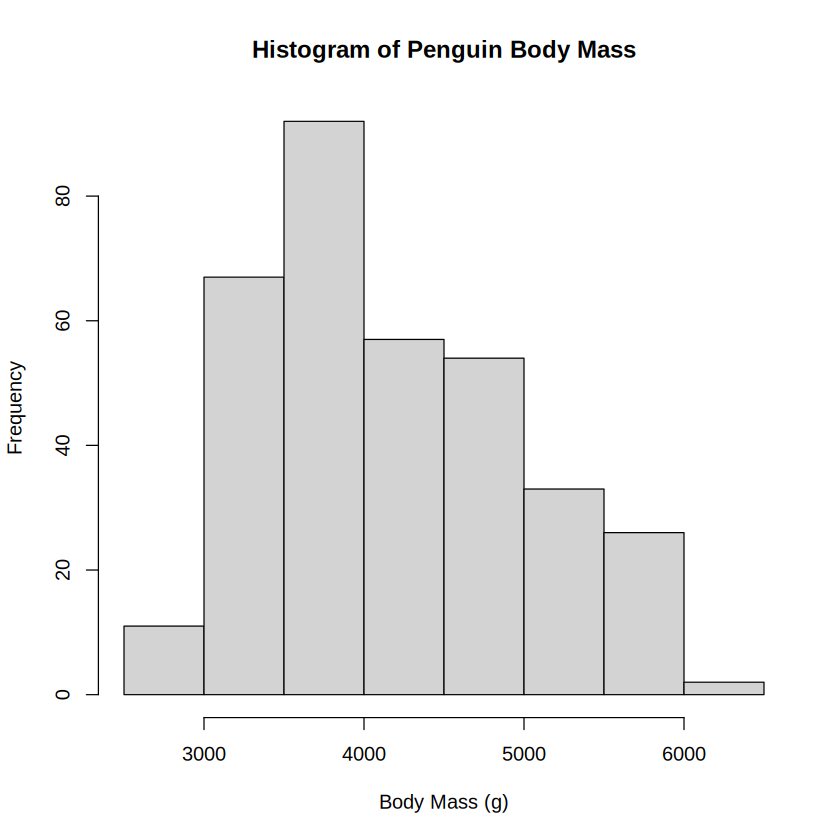

In [17]:
# Step 5: Histogram of Body Mass

hist(
  body_mass,
  main = "Histogram of Penguin Body Mass",
  xlab = "Body Mass (g)",
  ylab = "Frequency"
)

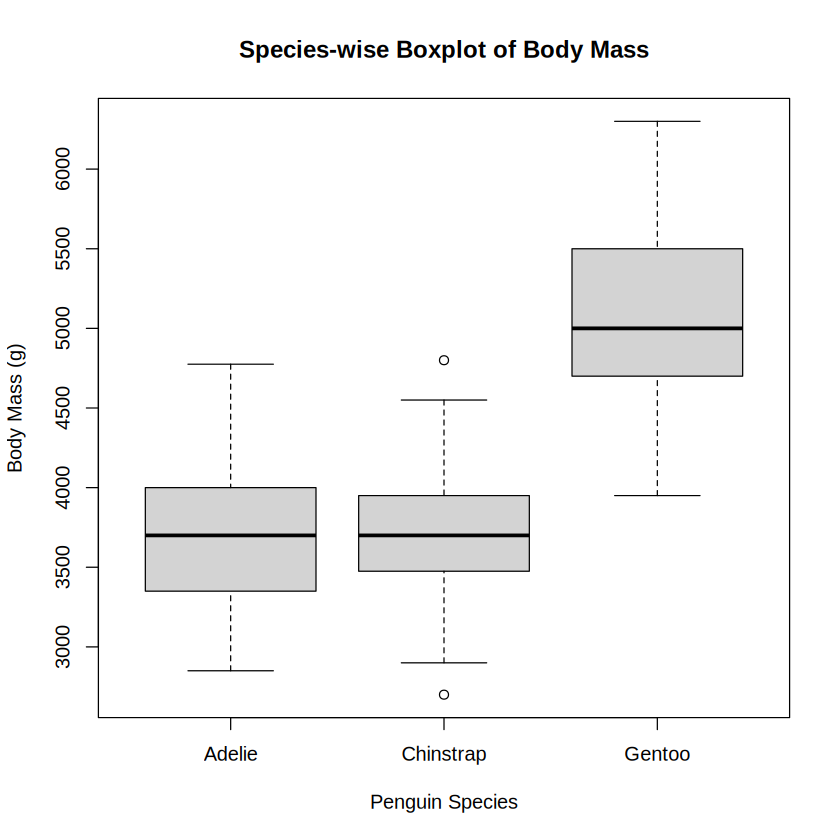

In [18]:
# Step 6: Species-wise Boxplot of Body Mass

boxplot(
  body_mass_g ~ species,
  data = penguins,
  main = "Species-wise Boxplot of Body Mass",
  xlab = "Penguin Species",
  ylab = "Body Mass (g)"
)

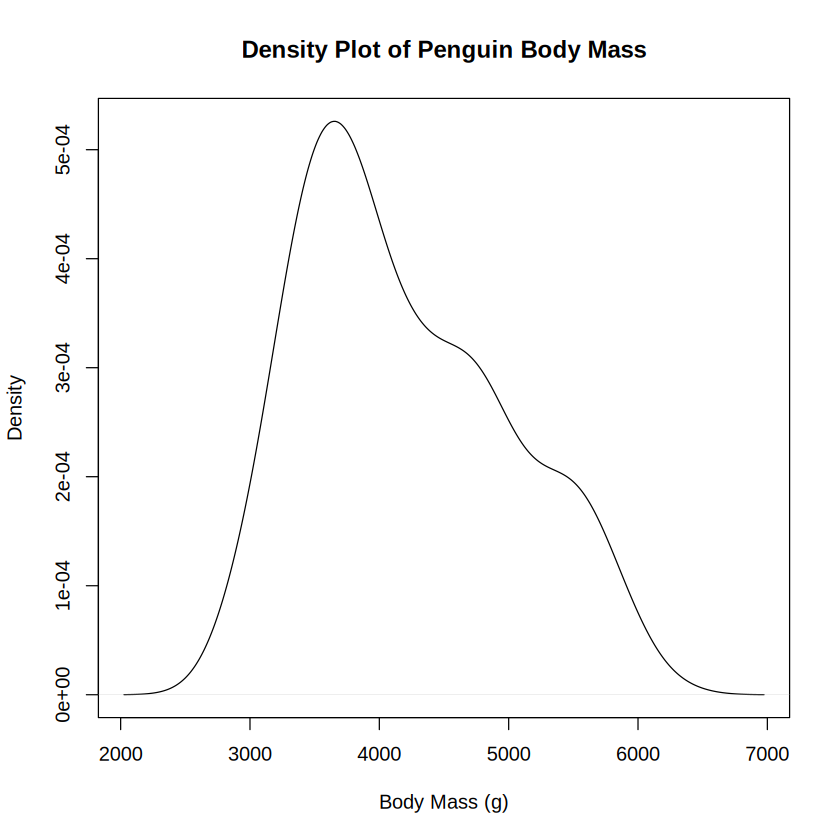

In [19]:
# Step 7: Density Plot of Body Mass

plot(
  density(body_mass),
  main = "Density Plot of Penguin Body Mass",
  xlab = "Body Mass (g)",
  ylab = "Density"
)

In [20]:
# Step 8: Hypothesis Testing

# H0: Mean body mass of male and female penguins is equal
# H1: Mean body mass of male and female penguins is different

female <- penguins$body_mass_g[
  penguins$sex == "female"
]

male <- penguins$body_mass_g[
  penguins$sex == "male"
]

female <- na.omit(female)
male <- na.omit(male)

length(female)
length(male)

mean(female)
mean(male)

[1] 165

[1] 168

[1] 3862.273

[1] 4545.685

In [21]:
  # Step 9: Shapiro-Wilk Normality Test

shapiro.test(female)

shapiro.test(male)


	Shapiro-Wilk normality test

data:  female
W = 0.91931, p-value = 6.155e-08



	Shapiro-Wilk normality test

data:  male
W = 0.92504, p-value = 1.227e-07


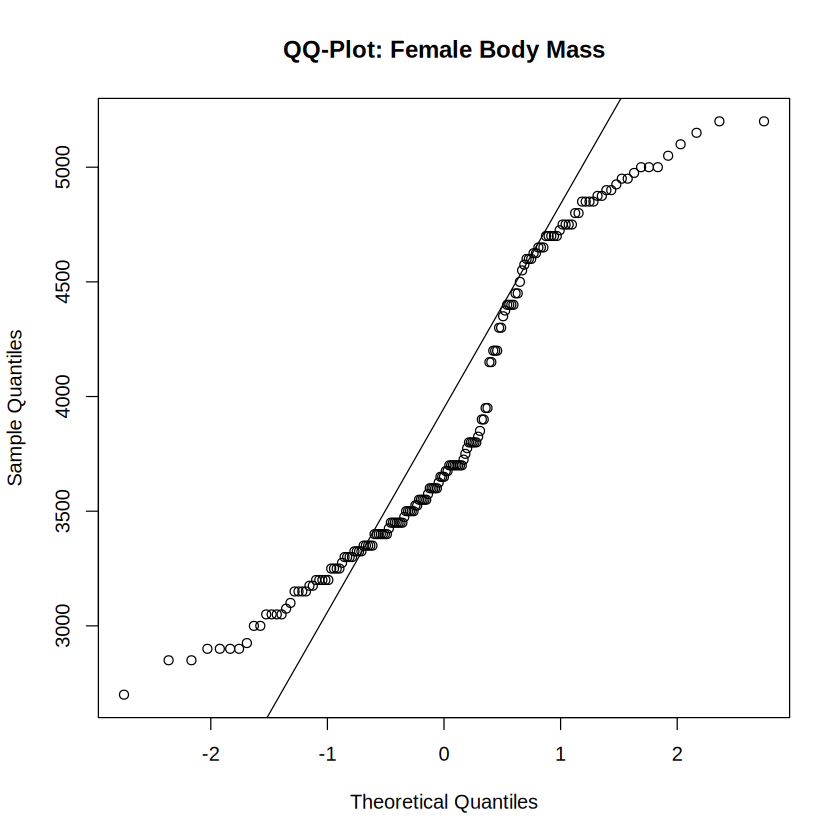

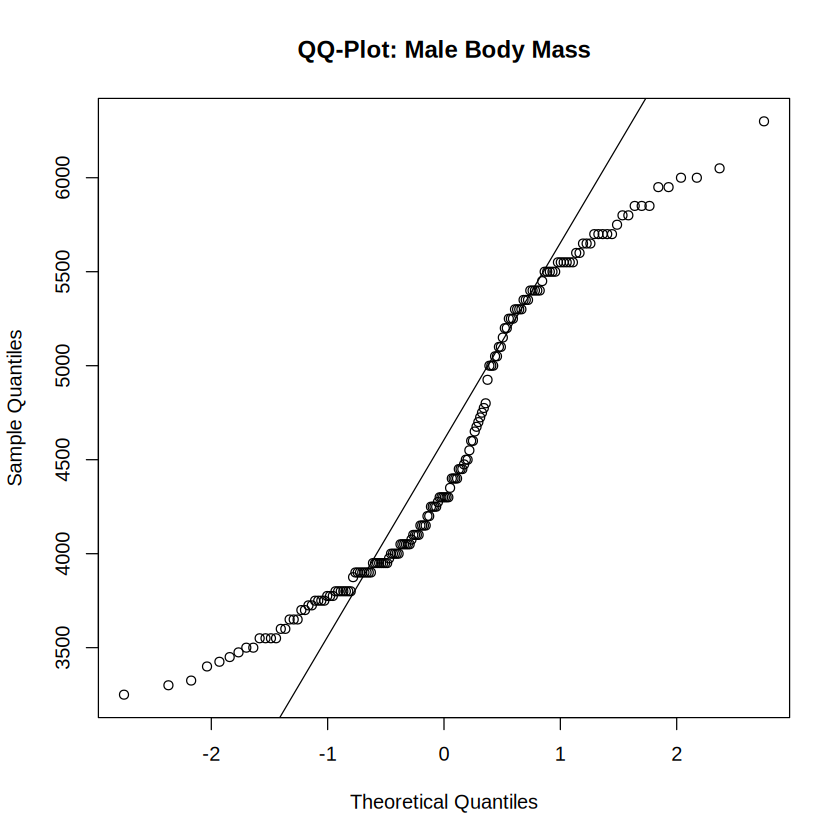

In [22]:
# Step 10: QQ-Plots

qqnorm(
  female,
  main = "QQ-Plot: Female Body Mass"
)
qqline(female)

qqnorm(
  male,
  main = "QQ-Plot: Male Body Mass"
)
qqline(male)

In [23]:
# Step 11: Independent Two-Sample t-Test

t_test <- t.test(
  male,
  female,
  var.equal = FALSE
)

t_test


	Welch Two Sample t-test

data:  male and female
t = 8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 526.2453 840.5783
sample estimates:
mean of x mean of y 
 4545.685  3862.273 


In [24]:
# Step 12: 95% Confidence Interval

t_test$conf.int

[1] 526.2453 840.5783
attr(,"conf.level")
[1] 0.95

In [25]:
# 95% CI for Difference in Mean Body Mass

mean(male) - mean(female)

t_test$conf.int

[1] 683.4118

[1] 526.2453 840.5783
attr(,"conf.level")
[1] 0.95

In [26]:
# Step 13: Cohen's d

n_male <- length(male)
n_female <- length(female)

pooled_sd <- sqrt(
  (
    (n_male - 1) * var(male) +
    (n_female - 1) * var(female)
  ) /
  (n_male + n_female - 2)
)

cohen_d <- (mean(male) - mean(female)) / pooled_sd

cohen_d

[1] 0.9362048

In [27]:
# Step 14: Interpretation of Hypothesis Test

t_test$p.value
cohen_d

if (t_test$p.value < 0.05) {
  cat("Reject H0: Male and female penguins have significantly different mean body masses.")
} else {
  cat("Fail to reject H0: There is insufficient evidence of a significant difference in mean body mass.")
}

[1] 4.793891e-16

[1] 0.9362048

Reject H0: Male and female penguins have significantly different mean body masses.

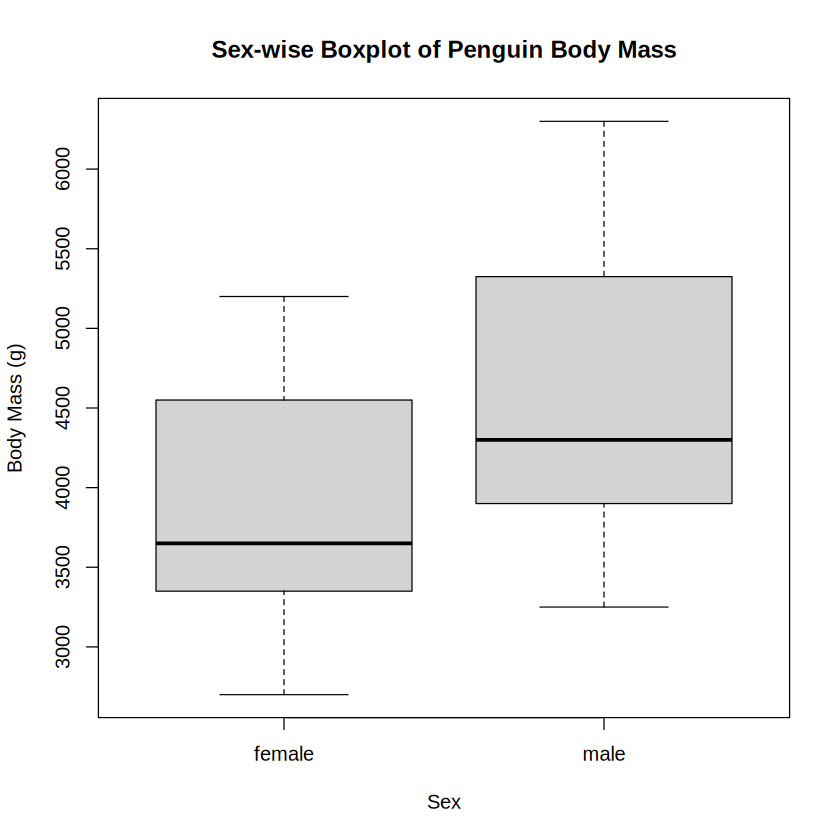

In [28]:
# Step 15: Sex-wise Boxplot of Body Mass

boxplot(
  body_mass_g ~ sex,
  data = penguins,
  main = "Sex-wise Boxplot of Penguin Body Mass",
  xlab = "Sex",
  ylab = "Body Mass (g)"
)

In [29]:
# Step 16: One-Way ANOVA

anova_model <- aov(
  body_mass_g ~ species,
  data = penguins
)

summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 146864214 73432107   343.6 <2e-16 ***
Residuals   339  72443483   213698                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

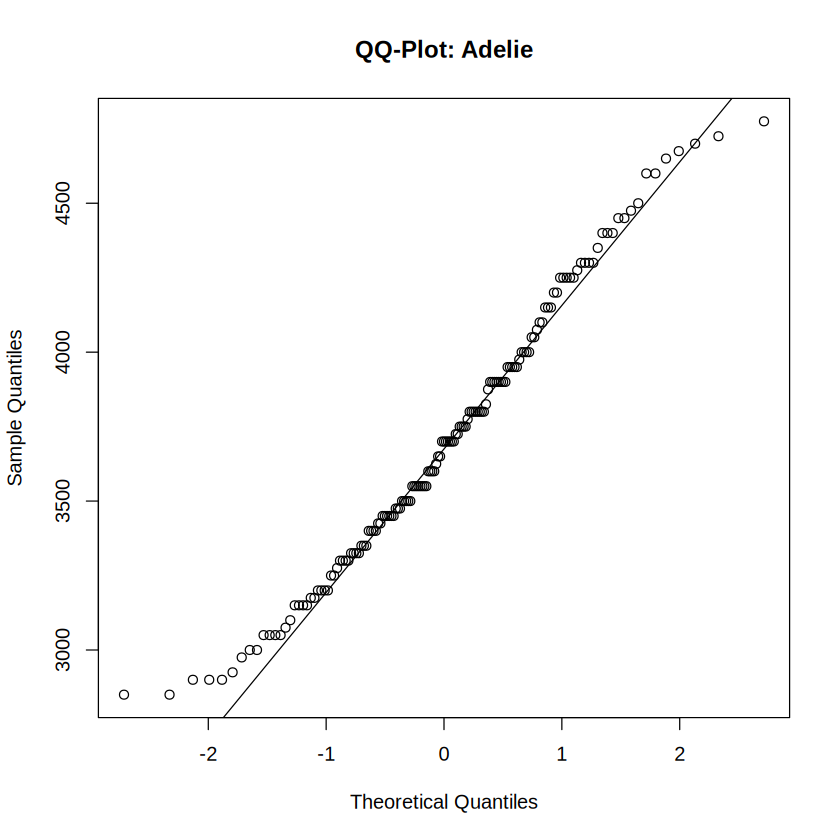

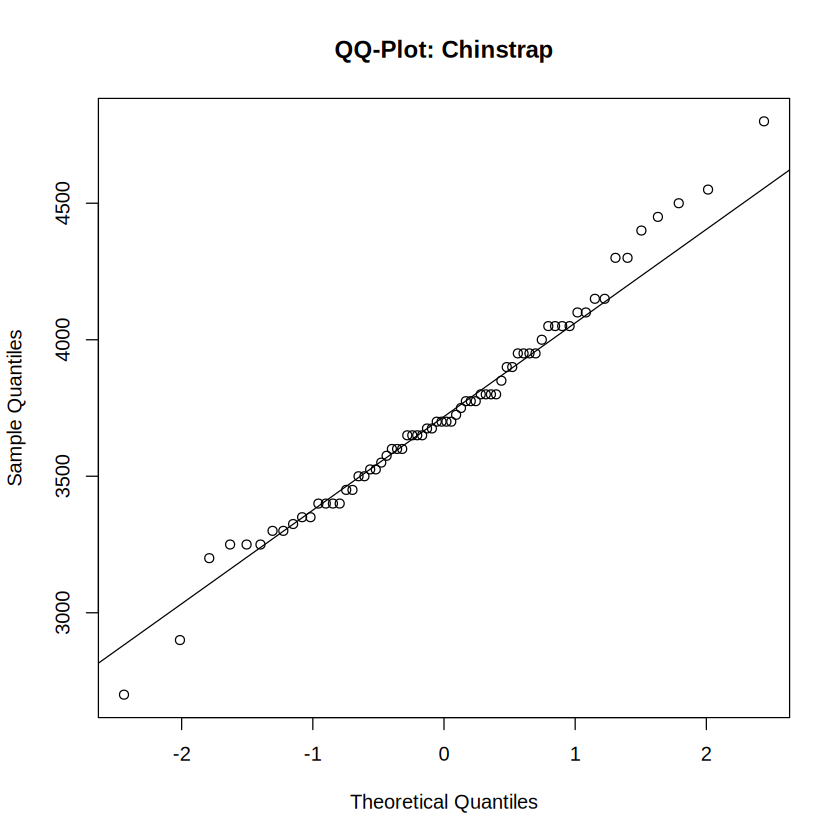

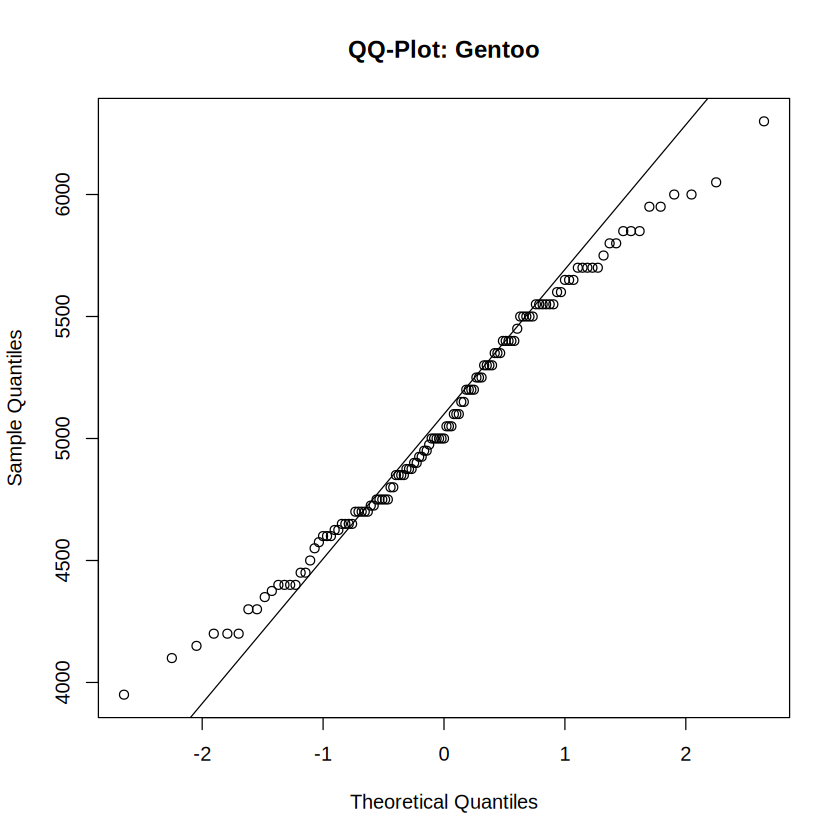

In [30]:
# Step 17: QQ-Plots for Body Mass by Species

adelie <- na.omit(penguins$body_mass_g[penguins$species == "Adelie"])
chinstrap <- na.omit(penguins$body_mass_g[penguins$species == "Chinstrap"])
gentoo <- na.omit(penguins$body_mass_g[penguins$species == "Gentoo"])

qqnorm(adelie, main = "QQ-Plot: Adelie")
qqline(adelie)

qqnorm(chinstrap, main = "QQ-Plot: Chinstrap")
qqline(chinstrap)

qqnorm(gentoo, main = "QQ-Plot: Gentoo")
qqline(gentoo)

In [31]:
# Step 18: Shapiro-Wilk Test by Species

shapiro.test(adelie)

shapiro.test(chinstrap)

shapiro.test(gentoo)


	Shapiro-Wilk normality test

data:  adelie
W = 0.98071, p-value = 0.0324



	Shapiro-Wilk normality test

data:  chinstrap
W = 0.98449, p-value = 0.5605



	Shapiro-Wilk normality test

data:  gentoo
W = 0.98593, p-value = 0.2336


In [32]:
# Step 19: Levene's Test

install.packages("car")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppEigen’, ‘pbkrtest’, ‘lme4’




In [33]:
# Levene's Test

library(car)

leveneTest(
  body_mass_g ~ species,
  data = penguins
)

Loading required package: carData



,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.120251,0.006445083
,339,NA,NA


In [34]:
# Step 20: One-Way ANOVA

anova_model <- aov(
  body_mass_g ~ species,
  data = penguins
)

summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 146864214 73432107   343.6 <2e-16 ***
Residuals   339  72443483   213698                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [35]:
# Step 21: ANOVA Result

anova_result <- summary(anova_model)[[1]]

F_value <- anova_result$`F value`[1]
p_value <- anova_result$`Pr(>F)`[1]
df1 <- anova_result$Df[1]
df2 <- anova_result$Df[2]

F_value
df1
df2
p_value

[1] 343.6263

[1] 2

[1] 339

[1] 2.892368e-82

In [36]:
#Tukey HSD

TukeyHSD(anova_model)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins)

$species
                       diff       lwr       upr     p adj
Chinstrap-Adelie   32.42598 -126.5002  191.3522 0.8806666
Gentoo-Adelie    1375.35401 1243.1786 1507.5294 0.0000000
Gentoo-Chinstrap 1342.92802 1178.4810 1507.3750 0.0000000


In [37]:
kruskal.test(
  body_mass_g ~ species,
  data = penguins
)


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 217.6, df = 2, p-value < 2.2e-16


In [38]:
# Step 23: Two-Way ANOVA

data2 <- na.omit(penguins[, c("body_mass_g", "species", "sex")])

model2 <- aov(
  body_mass_g ~ species * sex,
  data = data2
)

summary(model2)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [39]:
# Step 24: Flipper Length by Species

flipper_model <- aov(
  flipper_length_mm ~ species,
  data = penguins
)

summary(flipper_model)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

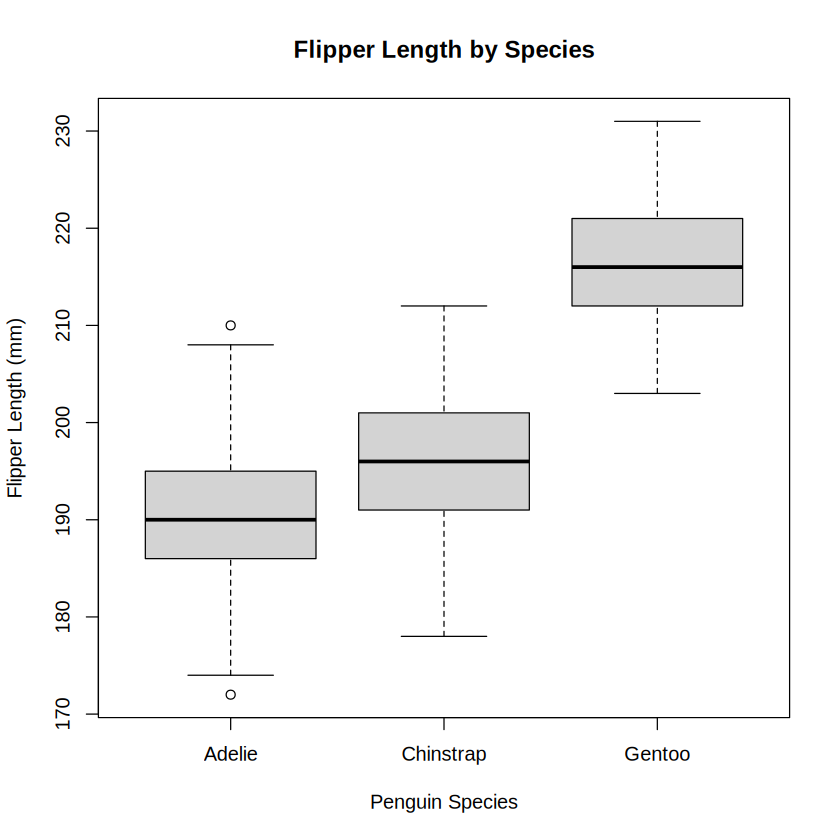

In [40]:
# Step 25: Flipper Length Comparison

boxplot(
  flipper_length_mm ~ species,
  data = penguins,
  main = "Flipper Length by Species",
  xlab = "Penguin Species",
  ylab = "Flipper Length (mm)"
)

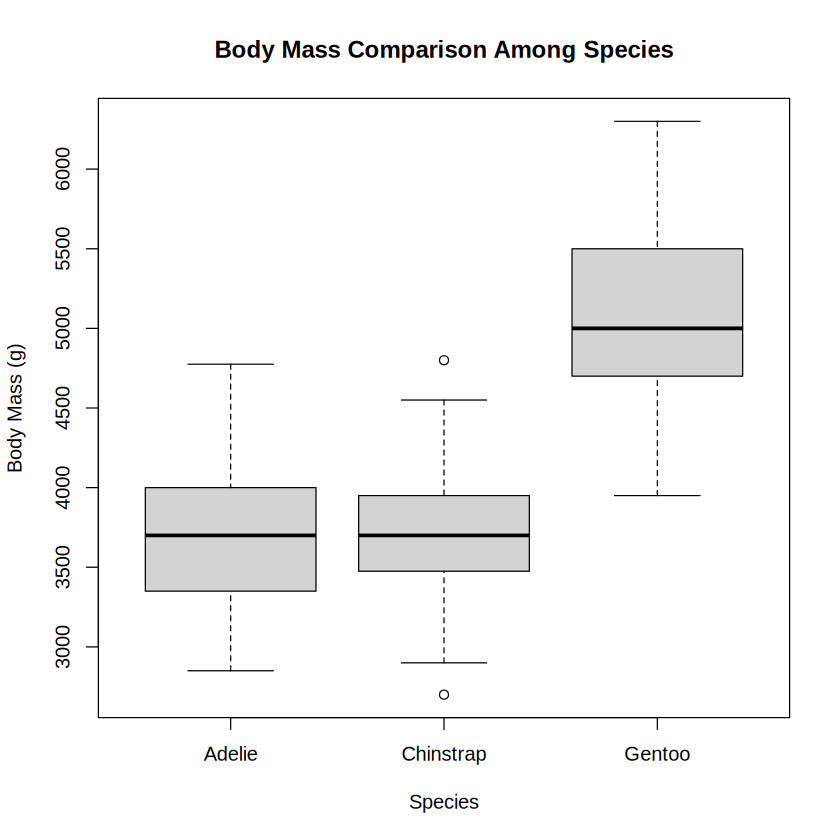

In [41]:
# Step 26: Group Comparison Plot

boxplot(
  body_mass_g ~ species,
  data = penguins,
  main = "Body Mass Comparison Among Species",
  xlab = "Species",
  ylab = "Body Mass (g)"
)

In [42]:
# Step 27: Summary

summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

In [43]:
summary(anova_model)

kruskal.test(body_mass_g ~ species, data = penguins)

summary(model2)

summary(flipper_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 146864214 73432107   343.6 <2e-16 ***
Residuals   339  72443483   213698                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 217.6, df = 2, p-value < 2.2e-16


             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [44]:
# Step 28: Flipper Length ANOVA Result

summary(flipper_model)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [45]:
# Step 28: Tukey HSD for Flipper Length

TukeyHSD(flipper_model)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins)

$species
                      diff       lwr       upr p adj
Chinstrap-Adelie  5.869887  3.586583  8.153191     0
Gentoo-Adelie    27.233349 25.334376 29.132323     0
Gentoo-Chinstrap 21.363462 19.000841 23.726084     0


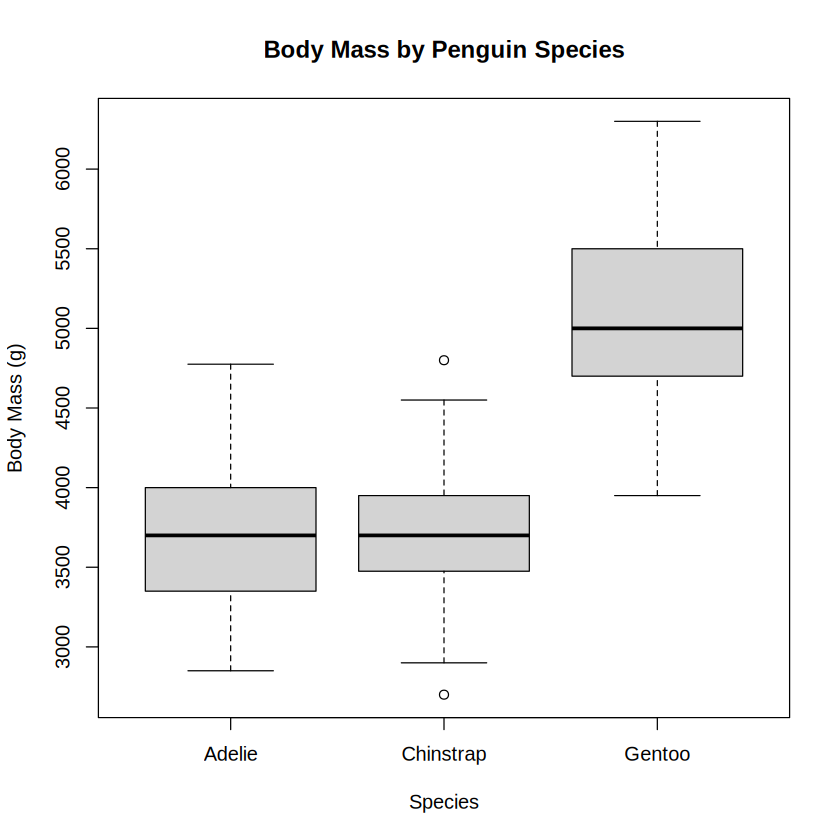

In [46]:
# Step 29: Group Comparison Plot

boxplot(
  body_mass_g ~ species,
  data = penguins,
  main = "Body Mass by Penguin Species",
  xlab = "Species",
  ylab = "Body Mass (g)"
)

## Conclusion

The Palmer Penguins dataset was analyzed using descriptive statistics, hypothesis testing, ANOVA, and non-parametric analysis in R. Body mass was compared across species and sex, and flipper length was also analyzed across species. The statistical tests and visualizations helped in understanding the differences in physical characteristics among penguins.